# Task: Edge Detection Filters 

**Goal:** apply every filter we covered to **your own picture**, compare the results, and explain what you see.

**Rules**
- Use your own image (a photo with clear objects and some texture works best, not a blank wall).
- Write the code yourself where you see `# TODO`. Hints are given, not solutions.
- Every plot needs a title. Use `plt.figure(figsize=...)` so images are readable.

**Submit:** this notebook with outputs visible + your answers.

## Part 0: Setup & Load Your Image

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = r"D:\AAST\SkyXperts\SkyXperts-Vision-Course\solved tasks\peacock.jpeg"

# TODO: load the image in grayscale and display it
img_grey= cv.imread(IMAGE_PATH, cv.IMREAD_GRAYSCALE)
# Hint: cv.imread(..., cv.IMREAD_GRAYSCALE), then plt.imshow(..., cmap="gray")
img = None
print(img_grey.shape)


(316, 404)


**Question 0:** What is the size (height × width) of your image? Why do we convert to grayscale before edge detection?

*Your answer:* Grayscale reduces the image to a single 2D matrix, that speed up the convolution operations needed for edge detection filters.

## Part 1: Gradients (Sobel)

Compute the horizontal and vertical derivatives, then the magnitude and orientation.

Formulas: `mag = sqrt(gx² + gy²)` and `θ = arctan2(gy, gx)`

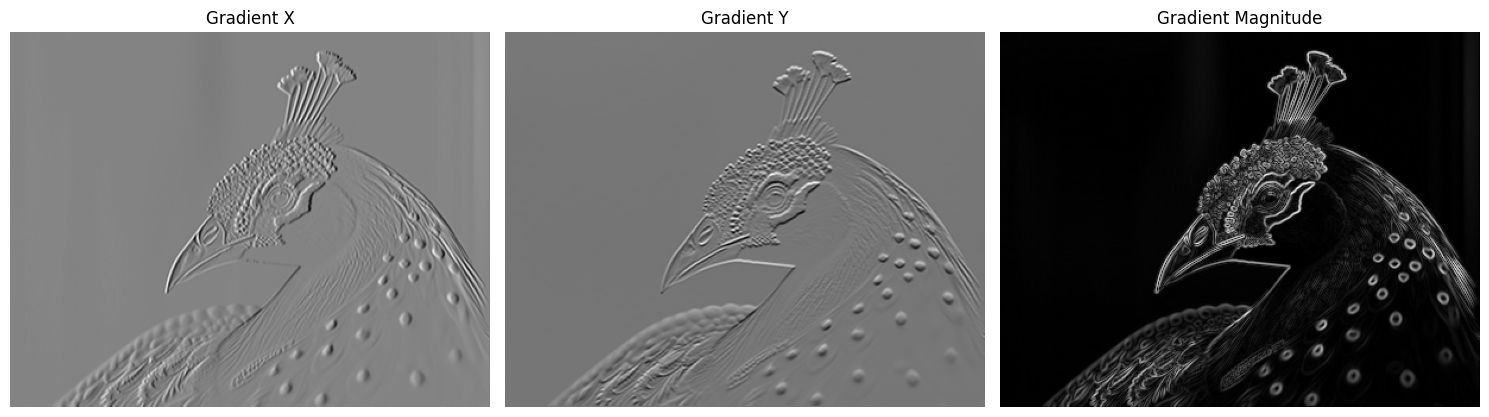

In [6]:
# TODO: compute grad_x and grad_y using cv2.Sobel with cv2.CV_64F and ksize=3
grad_x = cv.Sobel(img_grey, cv.CV_64F, 1, 0, ksize=3)
grad_y = cv.Sobel(img_grey, cv.CV_64F, 0, 1, ksize=3)

# TODO: compute magnitude and orientation (in degrees)
magnitude = cv.magnitude(grad_x, grad_y)
orientation = cv.phase(grad_x, grad_y, angleInDegrees=True)

magnitude = np.sqrt(grad_x**2 + grad_y**2)
orientation = np.arctan2(grad_y, grad_x)

# TODO: show grad_x, grad_y and magnitude side by side (1 row, 3 columns)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grad_x, cmap='gray')
plt.title('Gradient X')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad_y, cmap='gray')
plt.title('Gradient Y')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()



**Question 1a:** Which gradient (X or Y) highlights vertical lines in your image? Point out one object in your picture that proves it.

**Question 1b:** Why do we use `cv2.CV_64F` instead of the default `uint8` here? (Hint: what happens to negative values?)

*Your answers:* 
q1: - gradient x what proves it is : the vertical lines at the center of the image.

q2: - We use it instead of uint8 for gradient calculations because edge detection measures intensity changes(rate of change), which frequently produce negative values when transitioning from light(255) to dark(0). Since uint8 only supports +ve integers and automatically clips -ve numbers to zero, using it would permanently erase half of your edge data. A 64-bit float safely preserves these -ve transitions until you calculate the absolute magnitude, at which point all values become +ve and can be safely converted back to uint8 for display.

## Part 2: Laplacian

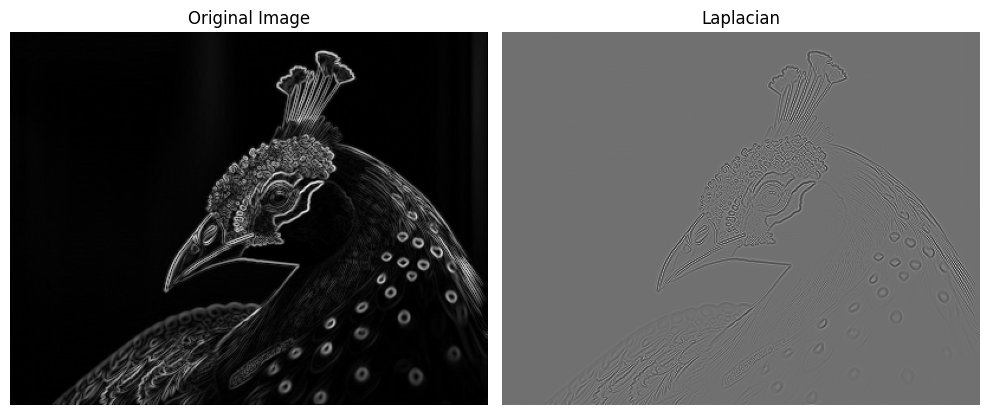

In [10]:
# TODO: apply the Laplacian and show it next to the sobel 
laplacian = cv.Laplacian(magnitude, cv.CV_64F)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(magnitude, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.tight_layout()
plt.show()


**Question 2:** What is the difference between what the Laplacian gives you and what the Sobel gradients gave you? Does it tell you the edge direction?

*Your answer:* Sobel uses horizontal and vertical gradients to show how strong an edge is and its direction. The Laplacian combines changes in both directions to highlight places where intensity changes quickly. it can find edges, but it does not tell us which dir it points to.

## Part 3: Canny

Try **three different threshold pairs** (low, high), for example a low pair, a medium pair, and a high pair.

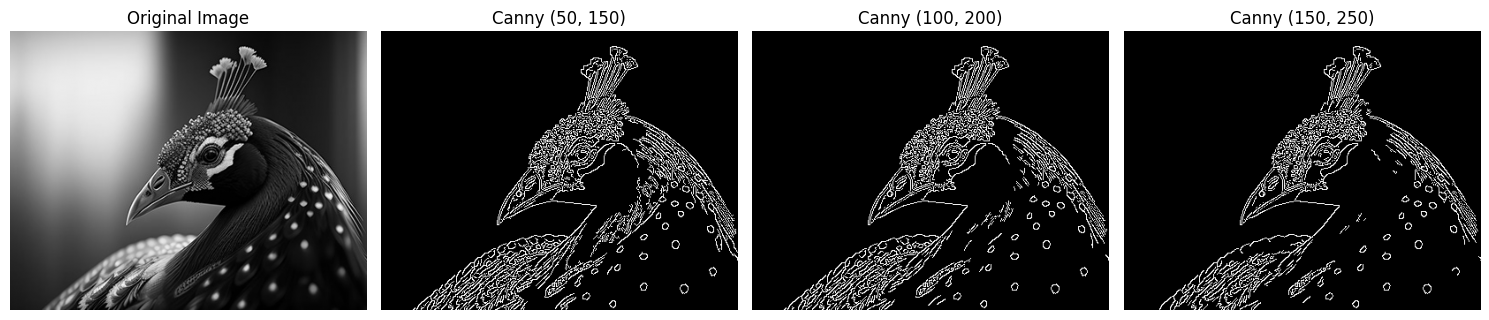

In [8]:
# TODO: run cv2.Canny with 3 different (low, high) threshold pairs
canny1 = cv.Canny(img_grey, 50, 150)
canny2 = cv.Canny(img_grey, 100, 200)
canny3 = cv.Canny(img_grey, 150, 250)

# TODO: show the original + the 3 results in one figure (1 row, 4 columns)
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(img_grey, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(canny1, cmap='gray')
plt.title('Canny (50, 150)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(canny2, cmap='gray')
plt.title('Canny (100, 200)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(canny3, cmap='gray')
plt.title('Canny (150, 250)')
plt.axis('off')

plt.tight_layout()
plt.show()


**Question 3a:** What happens to the edges as you increase the thresholds?


**Question 3b:** List the 5 steps of the Canny pipeline in order.

*Your answers:* 3a : As thresholds increase, weak edges disappear and stronger edges remain.

3b: The five Canny steps are: 
 - noise reduction, 
 - gradient calculation, 
 - keeping only sharpest edge pixels,
 - Mark edges as strong,weak or not edges,
 - Keep weak edges connected to strong edges.

## Part 4: Roberts & Prewitt (Your Own Kernels)

Define the kernels yourself as NumPy arrays and apply them with `cv2.filter2D`.

- Roberts: 2×2 kernels
- Prewitt: 3×3 kernels (X and Y)

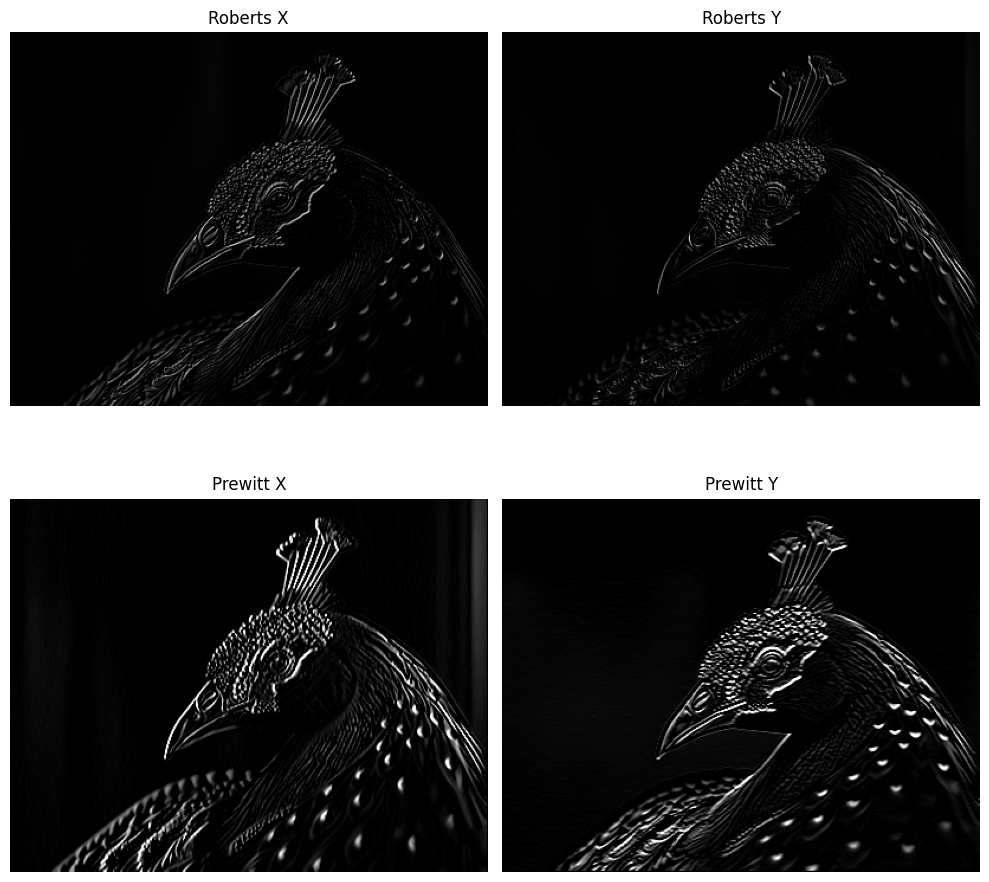

In [9]:
# TODO: define roberts_x, roberts_y, prewitt_x, prewitt_y
# - Roberts: 2×2 kernels
# - Prewitt: 3×3 kernels (X and Y)
roberts_x=np.array([[1, 0],[0, -1]], dtype=np.float32)
roberts_y=np.array([[0, 1],[-1, 0]], dtype=np.float32)
prewitt_x=np.array([[-1, 0, 1],[-1, 0, 1],[-1, 0, 1]], dtype=np.float32)
prewitt_y=np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)

# TODO: apply each with cv2.filter2D(img, -1, kernel)
roberts_x_result = cv.filter2D(img_grey, -1, roberts_x)
roberts_y_result = cv.filter2D(img_grey, -1, roberts_y)
prewitt_x_result = cv.filter2D(img_grey, -1, prewitt_x)
prewitt_y_result = cv.filter2D(img_grey, -1, prewitt_y)

# TODO: show the 4 results in a 2x2 grid
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)    
plt.imshow(roberts_x_result, cmap='gray')
plt.title('Roberts X')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(roberts_y_result, cmap='gray')
plt.title('Roberts Y')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(prewitt_x_result, cmap='gray')
plt.title('Prewitt X')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(prewitt_y_result, cmap='gray')
plt.title('Prewitt Y')
plt.axis('off')

plt.tight_layout()
plt.show()

**Question 4:** Which one (Roberts or Prewitt) looks noisier on your image? Why do you think that is (think about kernel size)?

*Your answer:* 
- Roberts looks noisier because its smaller 2×2 kernel is more sensitive to small pixel changes .

## Part 5: Sobel 3×3 vs 5×5

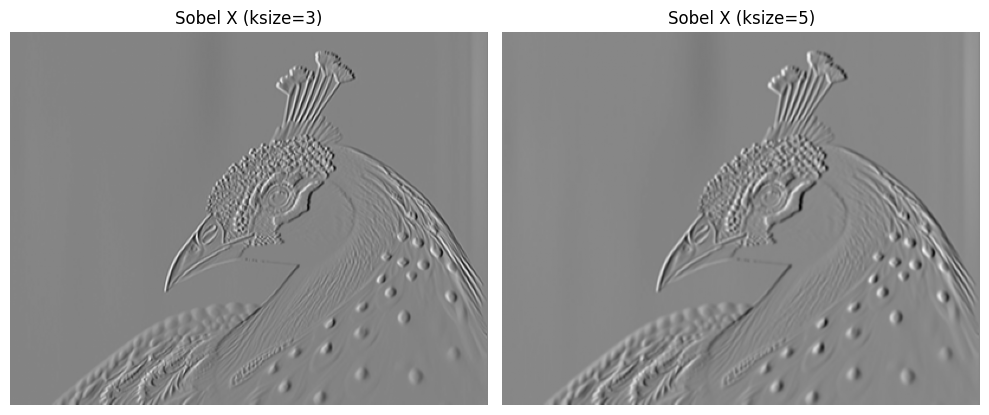

In [11]:
# TODO: apply Sobel in the X direction with ksize=3 and ksize=5, show side by side
sobel_x3= cv.Sobel(img_grey, cv.CV_64F, 1, 0, ksize=3)
sobel_x5= cv.Sobel(img_grey, cv.CV_64F, 1, 0, ksize=5)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sobel_x3, cmap='gray')
plt.title('Sobel X (ksize=3)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_x5, cmap='gray')
plt.title('Sobel X (ksize=5)')
plt.axis('off')

plt.tight_layout()
plt.show()

**Question 5:** Describe the visible difference between the two. When would you choose 5×5 over 3×3?

*Your answer:* 
- 5×5 blur looks smoother but loses more fine detail than 3×3. Choose 5×5 when the image has more noise and use 3×3 to preserve details.

## Part 6: Gaussian, LoG & DoG

1. Blur the image with a Gaussian.
2. Apply the Laplacian on the blurred image (**LoG**).
3. Subtract two Gaussian blurs with different sigmas (**DoG**).

Then repeat the DoG with a **second pair of sigmas** (for example `(1, 2)` and `(2, 4)`) and compare.

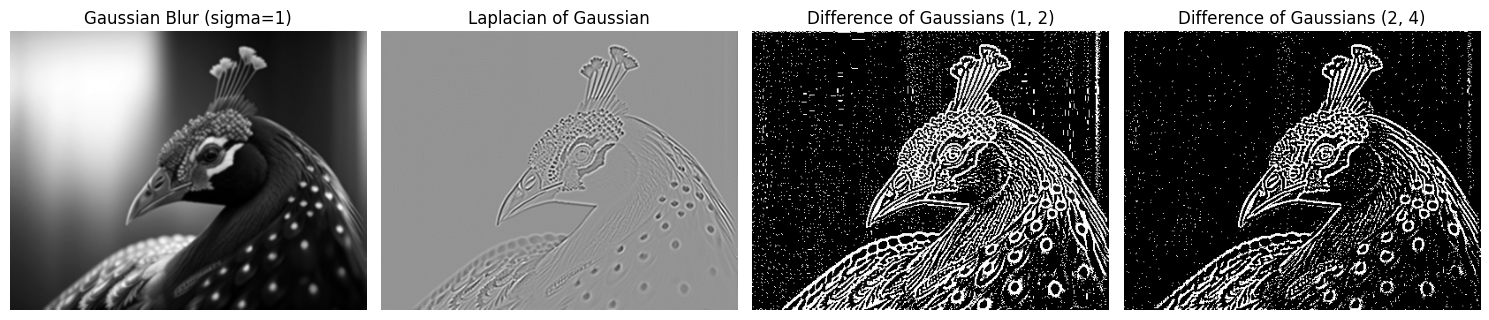

In [12]:
# TODO: blur, LoG, and DoG for the first sigma pair
# 1. Blur the image with a Gaussian.
# 2. Apply the Laplacian on the blurred image (**LoG**).
# 3. Subtract two Gaussian blurs with different sigmas (**DoG**).

# Then repeat the DoG with a **second pair of sigmas** (for example `(1, 2)` and `(2, 4)`) and compare.
blur1 = cv.GaussianBlur(img_grey, (5, 5), 1)
blur2 = cv.GaussianBlur(img_grey, (5, 5), 2)
log = cv.Laplacian(blur1, cv.CV_64F)
dog = blur1- blur2

# TODO: DoG for a second sigma pair
blur3 = cv.GaussianBlur(img_grey, (5, 5), 2)
blur4 = cv.GaussianBlur(img_grey, (5, 5), 4)
dog2 = blur3- blur4

# TODO: show everything in one figure
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(blur1, cmap='gray')
plt.title('Gaussian Blur (sigma=1)')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(log, cmap='gray')
plt.title('Laplacian of Gaussian')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(dog, cmap='gray')
plt.title('Difference of Gaussians (1, 2)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(dog2, cmap='gray')
plt.title('Difference of Gaussians (2, 4)')
plt.axis('off')

plt.tight_layout()
plt.show()

**Question 6a:** Why do we blur before applying the Laplacian?

**Question 6b:** What changes in the DoG result when you increase the sigmas?

**Question 6c:** Which algorithm uses DoG for blob detection?

*Your answers:* 
- 6a: Blurring removes small noise that could create false edges in the Laplacian result.
- 6b: Increasing the sigmas makes the DoG result focus on larger image features and ignore finer details.
- 6c: SIFT uses DoG to find keypoints in an image.

## Part 7: Noise Experiment

Add noise to your image and see which filters survive.

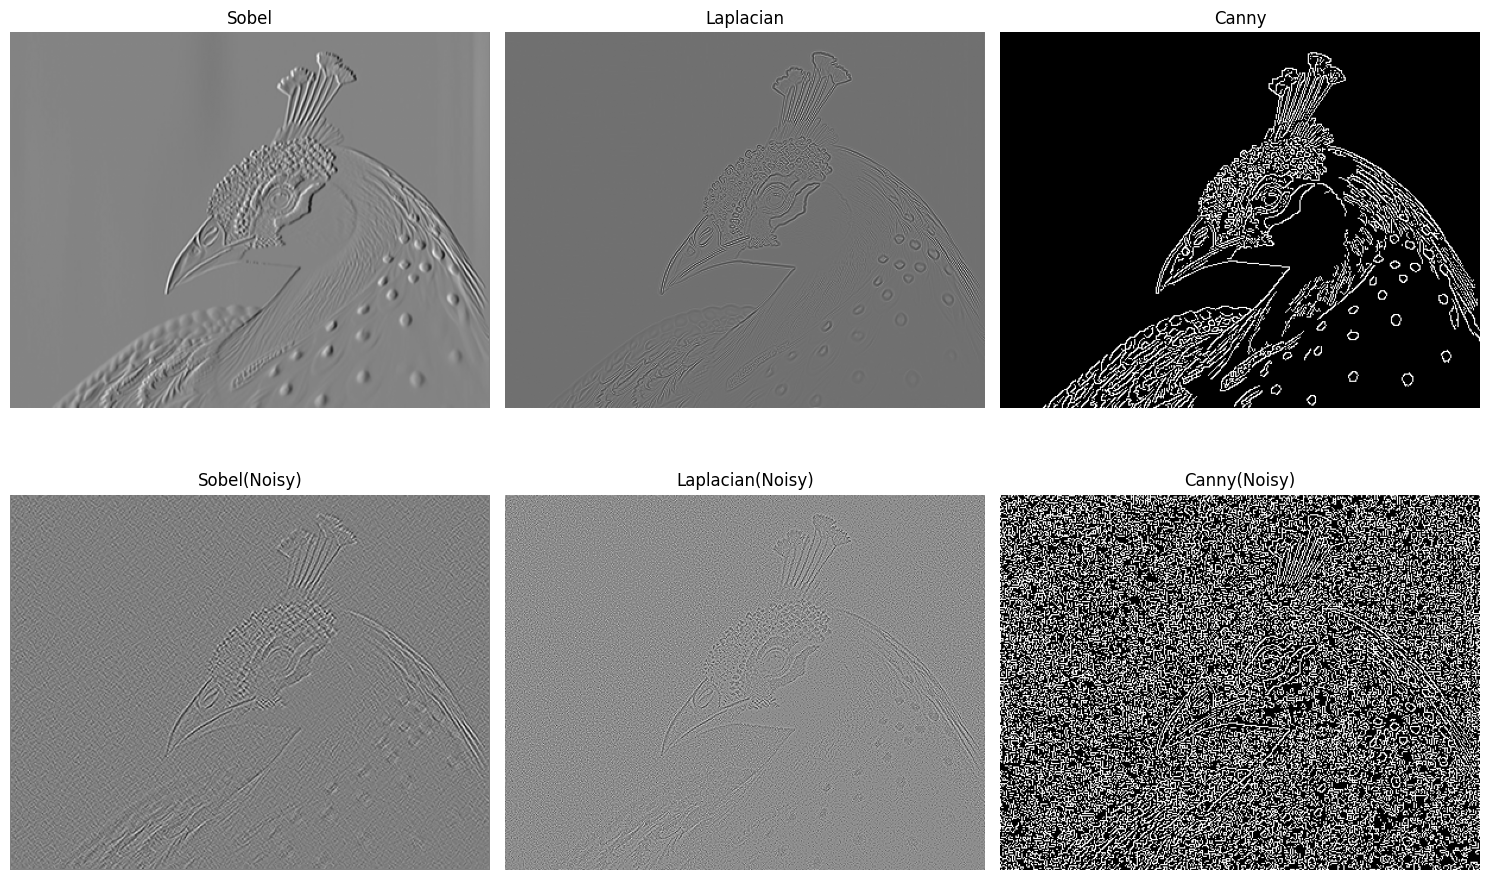

In [14]:
# TODO: create a noisy copy of your image
copy = img_grey.copy()
noise = np.random.normal(0, 25, copy.shape)
noisy = np.clip(copy + noise, 0, 255).astype(np.uint8)

# TODO: apply Sobel (3x3), Laplacian and Canny on the NOISY image
sobel_noisy = cv.Sobel(noisy, cv.CV_64F, 1, 1, ksize=3)
laplacian_noisy = cv.Laplacian(noisy, cv.CV_64F)
canny_noisy = cv.Canny(noisy, 50, 150)

# TODO: show the 3 results next to the same 3 results from the clean image (2 rows x 3 columns)
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(sobel_x3, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(canny1, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(sobel_noisy, cmap='gray')
plt.title('Sobel(Noisy)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(laplacian_noisy, cmap='gray')
plt.title('Laplacian(Noisy)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(canny_noisy, cmap='gray')
plt.title('Canny(Noisy)')
plt.axis('off')

plt.tight_layout()
plt.show()



**Question 7:** Which filter was hurt the most by noise, and which handled it best? Explain why, using what you know about derivatives and smoothing.

*Your answer:* 
 - The most hurt by noise is canny and the one handeled it the best is sobel,noise creates extra intensity changes that can appear as false edges. Sobel’s 3×3 kernel smooths nearby pixels slightly and canny showed more noise because its thresholds were likely too low, so weak noise edges were kept.

6:2

## Part 8: Final Comparison & Conclusion

Make one summary figure showing: Original, Sobel magnitude, Laplacian, Canny, LoG, DoG.

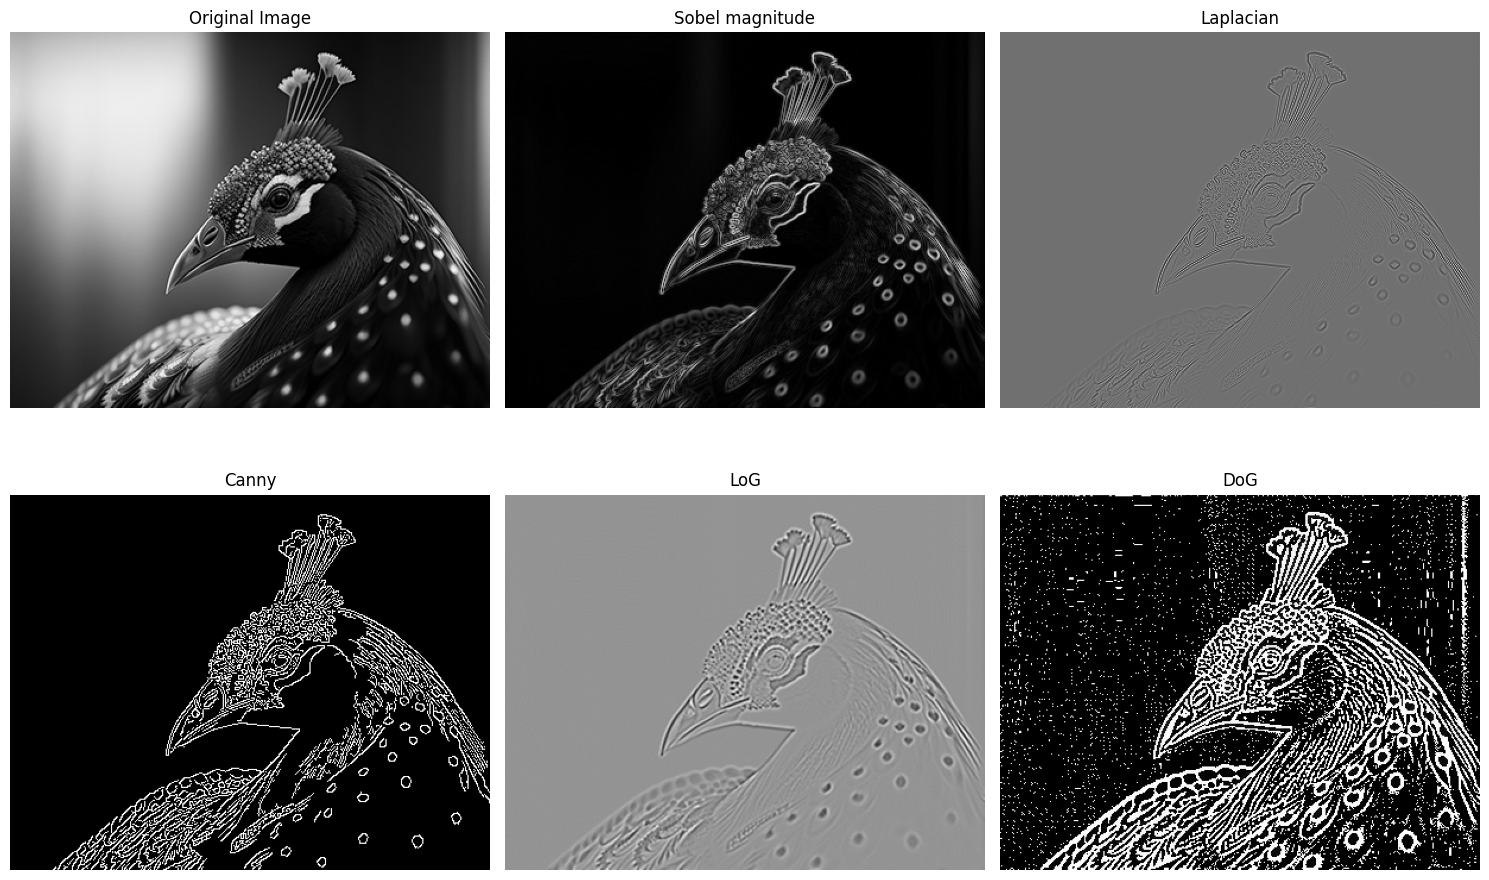

In [15]:
# TODO: 2x3 grid with all six results and titles

plt.figure(figsize=(15, 10))


plt.subplot(2, 3, 1)
plt.imshow(img_grey, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude, cmap='gray')
plt.title('Sobel magnitude')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(canny1, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(log, cmap='gray')
plt.title('LoG')
plt.axis('off')


plt.subplot(2, 3, 6)
plt.imshow(dog, cmap='gray')
plt.title('DoG')
plt.axis('off')

plt.tight_layout()
plt.show()




**Final Question:** If you had to pick one method to detect the edges of objects in **your** image, which would you choose and why? Mention at least two trade-offs (noise, detail, thickness of edges, speed...).

*Your answer:* 
- I would choose Sobel for my image because it looked cleaner. It was less affected by noise, but its edges are thicker and less precise than Canny’s. sobel is also simpler and faster.

### Bonus (optional)
- Try your code on a second image with very different content (a face, text, a landscape) and describe what changed.
- Combine Sobel X and Y into the magnitude **without** using `np.sqrt` (hint: `cv2.magnitude`) and check that you get the same result.

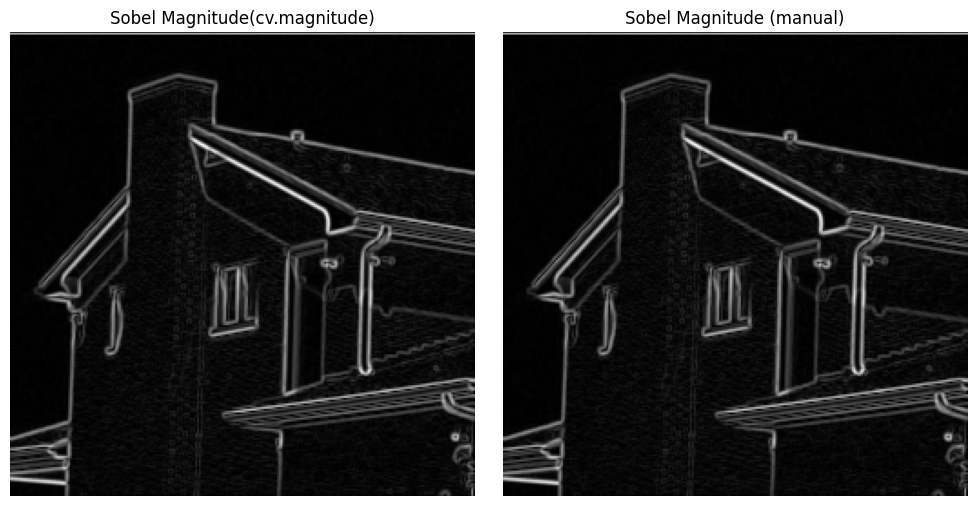

In [ ]:
house = cv.imread(r"D:\AAST\SkyXperts\SkyXperts-Vision-Course\solved tasks\house.jpg", cv.IMREAD_GRAYSCALE)
grad_x_house = cv.Sobel(house, cv.CV_64F, 1, 0)
grad_y_house = cv.Sobel(house, cv.CV_64F, 0, 1)
magnitude_house = cv.magnitude(grad_x_house, grad_y_house)
magnitude_house1 = np.sqrt(grad_x_house**2 + grad_y_house**2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)    
plt.imshow(magnitude_house, cmap='gray')
plt.title('Sobel Magnitude(cv.magnitude)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_house1, cmap='gray')
plt.title('Sobel Magnitude (manual)')
plt.axis('off')

plt.tight_layout()
plt.show()


